# Uncertain Volatility: Price-Level vs Log-Moneyness Fitting

This notebook compares two parameterisations of the uncertain volatility backbone:

1. **Log-moneyness (existing):** 3-state displaced-diffusion mixture. Each state $i$ has weight $w_i$, displacement $\beta_i$, log-normal vol $\sigma_{ln,i}$, and normal vol $\sigma_{n,i} = \sigma_{ln,i} \cdot S_\text{ref}$.

2. **Price-level (new):** 3-state pure Bachelier (normal) mixture. Each state $i$ has weight $w_i$ and normal vol $\sigma_{N,i}$ (in absolute price units per $\sqrt{\text{yr}}$). No displacement parameter is needed.

Both models feed a mixture price into a Black-Scholes implied-vol solver to extract ATM IV.

**In theory** the two fits should produce similar ATM backbones because at the money the log-normal and normal dynamics coincide (up to a scaling that the optimiser absorbs).

## 1. Imports & Data Load

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
import pickle
import os

import option_pricers as op
import importlib
importlib.reload(op)

In [2]:
TARGET_TAU = 30 / 365
R = 0.02

def regime(year):
    if year <= 2017:
        return 'Low Vol (2015-17)'
    elif year <= 2019:
        return 'Transition (2018-19)'
    elif year == 2020:
        return 'COVID'
    else:
        return 'Post-COVID'

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',
    'Transition (2018-19)': '#d62728',
    'COVID':                '#1f77b4',
    'Post-COVID':           '#2ca02c',
}

In [3]:
iv1m_df = pd.read_csv('./processed_data/1M_ATM.csv', parse_dates=['datetime'])
iv1m_df['year'] = iv1m_df['datetime'].dt.year
if 'regime' not in iv1m_df.columns:
    iv1m_df['regime'] = iv1m_df['year'].apply(regime)

print(f'Loaded iv1m_df: {len(iv1m_df)} rows')
print(iv1m_df.head())

Loaded iv1m_df: 2405 rows
   Unnamed: 0            datetime      spot  atm_iv_1m  year  \
0           0 2015-01-02 16:15:00  2055.050   0.131261  2015   
1           1 2015-01-05 16:15:00  2021.700   0.157472  2015   
2           2 2015-01-06 16:15:00  2004.165   0.158880  2015   
3           3 2015-01-07 16:15:00  2025.225   0.155366  2015   
4           4 2015-01-08 16:15:00  2061.885   0.131166  2015   

              regime  
0  Low Vol (2015-17)  
1  Low Vol (2015-17)  
2  Low Vol (2015-17)  
3  Low Vol (2015-17)  
4  Low Vol (2015-17)  


## 2. Load Existing Log-Moneyness Fits

In [4]:
with open('./processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_ln = pickle.load(f)

print('Log-moneyness regimes:', list(fits_ln.keys()))
for reg, info in fits_ln.items():
    p = info['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    print(f'  {reg}: converged={info["success"]}, MSE={info["fun"]:.6f}')
    print(f'    weights = {w}')
    print(f'    betas   = {p[3:6]}')
    print(f'    sigmas_ln = {np.abs(p[6:9])}')

Log-moneyness regimes: ['COVID', 'Low Vol (2015-17)', 'Post-COVID', 'Transition (2018-19)']
  COVID: converged=True, MSE=0.005632
    weights = [0.25357747 0.26061675 0.48580577]
    betas   = [0.1353998 0.1       0.1      ]
    sigmas_ln = [0.01       0.01       0.23575003]
  Low Vol (2015-17): converged=True, MSE=0.000795
    weights = [0.38729804 0.34041025 0.27229171]
    betas   = [0.89503297 0.90142764 0.1       ]
    sigmas_ln = [0.01       0.01       0.34337202]
  Post-COVID: converged=True, MSE=0.002463
    weights = [0.37670764 0.33271539 0.29057697]
    betas   = [0.91204453 0.87213264 0.18438326]
    sigmas_ln = [0.01       0.01       0.51681146]
  Transition (2018-19): converged=True, MSE=0.000907
    weights = [0.38389811 0.33819452 0.27790737]
    betas   = [0.88392403 0.89132872 0.1       ]
    sigmas_ln = [0.01       0.01       0.40077744]


## 3. Bachelier (Normal) Pricing Functions

The Bachelier model prices a call under the assumption that the underlying follows arithmetic Brownian motion:

$$C = e^{-rT}\left[(S - K)\,\Phi(d) + \sigma_N \sqrt{T}\,\phi(d)\right], \quad d = \frac{S - K}{\sigma_N\sqrt{T}}$$

For the mixture, the model price is $\sum_i w_i \, C_i^{\text{Bachelier}}$ and we then extract a Black-Scholes implied vol via the usual solver.

In [5]:
def bachelier_call(S, K, r, sigma_N, T):
    if sigma_N <= 0 or T <= 0:
        return max(S - K, 0.0) * np.exp(-r * T)
    d = (S - K) / (sigma_N * np.sqrt(T))
    price = np.exp(-r * T) * (
        (S - K) * norm.cdf(d) + sigma_N * np.sqrt(T) * norm.pdf(d)
    )
    return max(price, 0.0)


def uncertain_backbone_price(S, K, r, T, weights, sigmas_N):
    prices = [bachelier_call(S, K, r, sigma_N, T) for sigma_N in sigmas_N]
    model_price = np.dot(weights, prices)
    model_vol = op.impliedVolatility(S, K, r, model_price, T, 'call')
    return model_vol

## 4. Price-Level Loss Function & Fitting

In [6]:
def loss_price(params, S_data, iv_data, r, T):
    raw_weights = params[0:3]
    sigmas_N = params[3:6]

    weights = np.exp(raw_weights) / np.sum(np.exp(raw_weights))

    if np.any(sigmas_N <= 0):
        return 1e6

    model_ivs = []
    for S in S_data:
        try:
            iv = uncertain_backbone_price(S, S, r, T, weights, sigmas_N)
            if np.isnan(iv) or iv <= 0:
                return 1e6
            model_ivs.append(iv)
        except Exception:
            return 1e6

    return np.mean((np.array(model_ivs) - np.array(iv_data))**2)

In [7]:
init_price = np.array([
    0.3, 0.3, 0.4,
    50.0, 150.0, 400.0
])

bounds_price = [
    (None, None), (None, None), (None, None),
    (1.0, 1000.0), (1.0, 1000.0), (1.0, 1000.0)
]

fits_price = {}

for regime_name, g in iv1m_df.groupby('regime'):
    S_data = g['spot'].values
    iv_data = g['atm_iv_1m'].values

    res = minimize(
        loss_price,
        init_price,
        args=(S_data, iv_data, R, TARGET_TAU),
        method='L-BFGS-B',
        bounds=bounds_price,
        options={'maxiter': 1000}
    )

    fits_price[regime_name] = {
        'params': res.x,
        'success': res.success,
        'fun': res.fun,
        'niter': res.nit
    }

    p = res.x
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    print(f'\n{regime_name}:')
    print(f'  Converged: {res.success},  MSE: {res.fun:.6f},  Iter: {res.nit}')
    print(f'  weights:   {w}')
    print(f'  sigmas_N:  {np.abs(p[3:6])}')


COVID:
  Converged: True,  MSE: 0.005488,  Iter: 5
  weights:   [9.09816360e-10 2.04597283e-09 9.99999997e-01]
  sigmas_N:  [ 50.05392924 150.07072967 703.28246415]



Low Vol (2015-17):
  Converged: True,  MSE: 0.000722,  Iter: 5
  weights:   [0.19017735 0.20131198 0.60851067]
  sigmas_N:  [ 50.00115208 150.0021632  400.00374395]



Post-COVID:
  Converged: True,  MSE: 0.002549,  Iter: 10
  weights:   [4.82903166e-73 5.29540506e-81 1.00000000e+00]
  sigmas_N:  [ 50.07814346 150.18556678 776.33199237]



Transition (2018-19):
  Converged: True,  MSE: 0.000904,  Iter: 2
  weights:   [1.20831510e-05 1.14826321e-05 9.99976434e-01]
  sigmas_N:  [ 50.00590452 150.01795642 400.0547972 ]


## 5. Side-by-Side ATM Plots

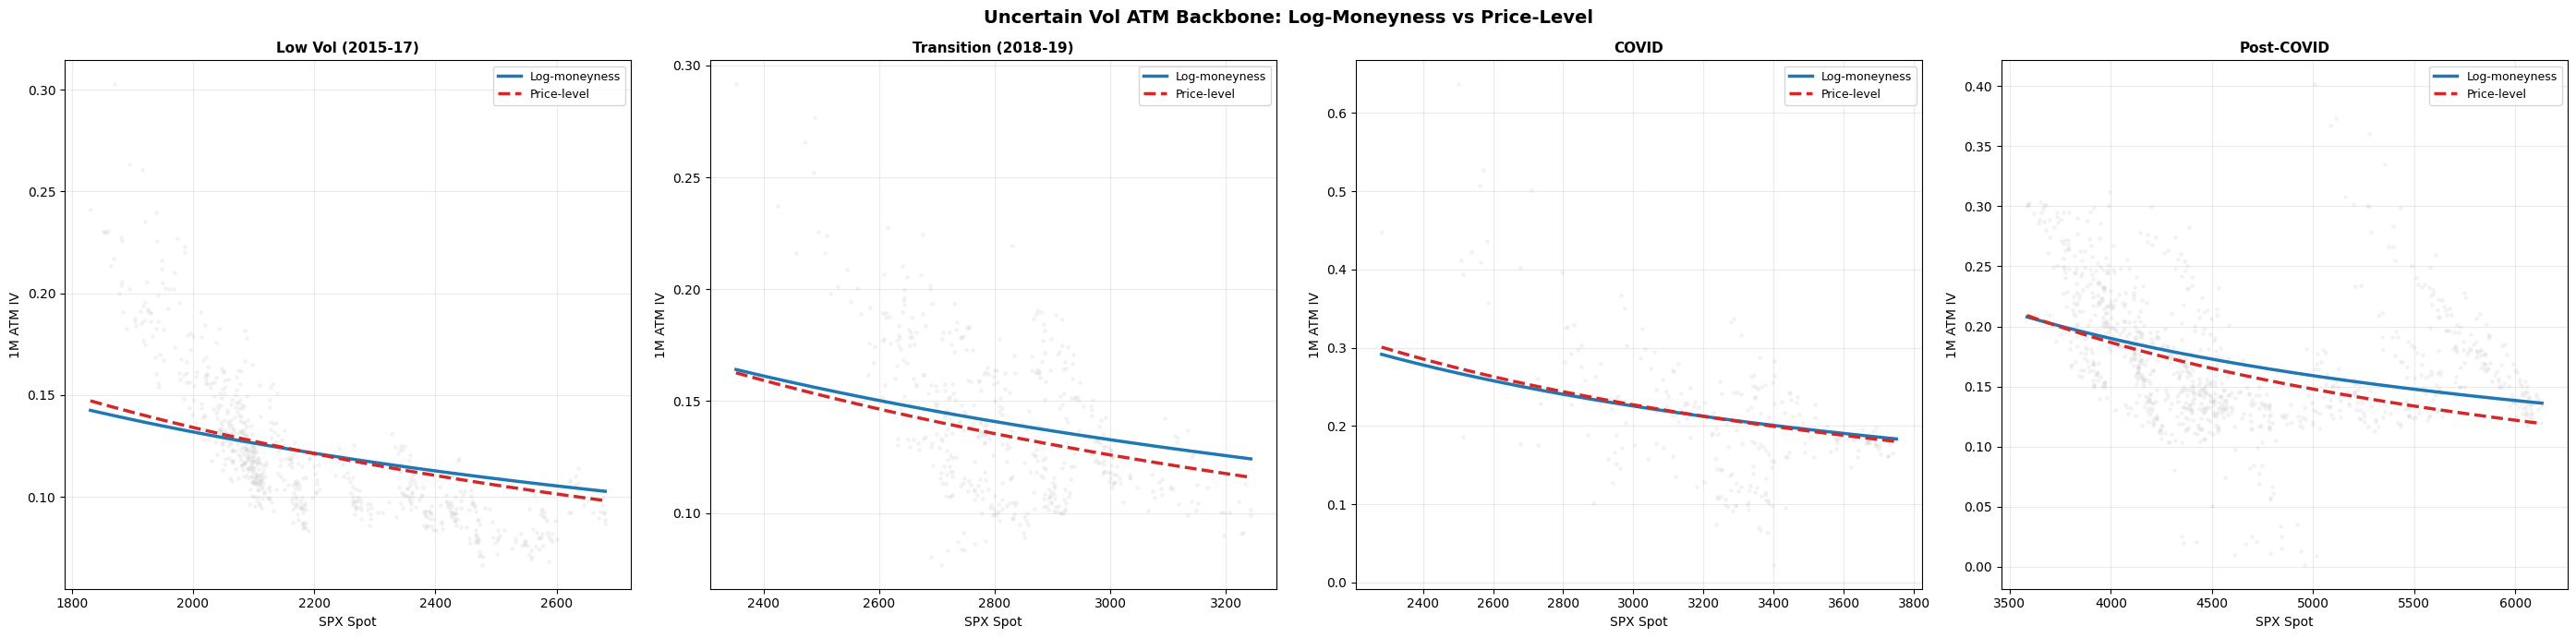

In [8]:
regimes = ['Low Vol (2015-17)', 'Transition (2018-19)', 'COVID', 'Post-COVID']

fig, axes = plt.subplots(1, 4, figsize=(28, 7), sharey=False)

for idx, reg in enumerate(regimes):
    ax = axes[idx]
    g = iv1m_df[iv1m_df['regime'] == reg]

    ax.scatter(g['spot'], g['atm_iv_1m'], s=6, alpha=0.2, color='lightgray', zorder=0)

    S_min = g['spot'].min()
    S_max = g['spot'].max()
    S_grid = np.linspace(S_min, S_max, 200)

    # --- Log-moneyness fit ---
    ln_info = fits_ln[reg]
    p_ln = ln_info['params']
    w_ln = np.exp(p_ln[:3]) / np.sum(np.exp(p_ln[:3]))
    betas = p_ln[3:6]
    sigmas_ln = np.abs(p_ln[6:9])
    S_ref = g['spot'].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)

    fitted_ln = []
    for S in S_grid:
        try:
            iv = op.uncertain_backbone(S, S, R, TARGET_TAU, w_ln, betas, sigmas_n, sigmas_ln)
            fitted_ln.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            fitted_ln.append(np.nan)

    ax.plot(S_grid, fitted_ln, color='#1f77b4', linewidth=2.5, label='Log-moneyness', zorder=2)

    # --- Price-level fit ---
    pr_info = fits_price[reg]
    p_pr = pr_info['params']
    w_pr = np.exp(p_pr[:3]) / np.sum(np.exp(p_pr[:3]))
    sigmas_N = np.abs(p_pr[3:6])

    fitted_pr = []
    for S in S_grid:
        try:
            iv = uncertain_backbone_price(S, S, R, TARGET_TAU, w_pr, sigmas_N)
            fitted_pr.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            fitted_pr.append(np.nan)

    ax.plot(S_grid, fitted_pr, color='#d62728', linewidth=2.5, linestyle='--', label='Price-level', zorder=3)

    ax.set_xlabel('SPX Spot', fontsize=10)
    ax.set_ylabel('1M ATM IV', fontsize=10)
    ax.set_title(reg, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.25)

plt.suptitle('Uncertain Vol ATM Backbone: Log-Moneyness vs Price-Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Overlay on Single Plot (All Regimes)

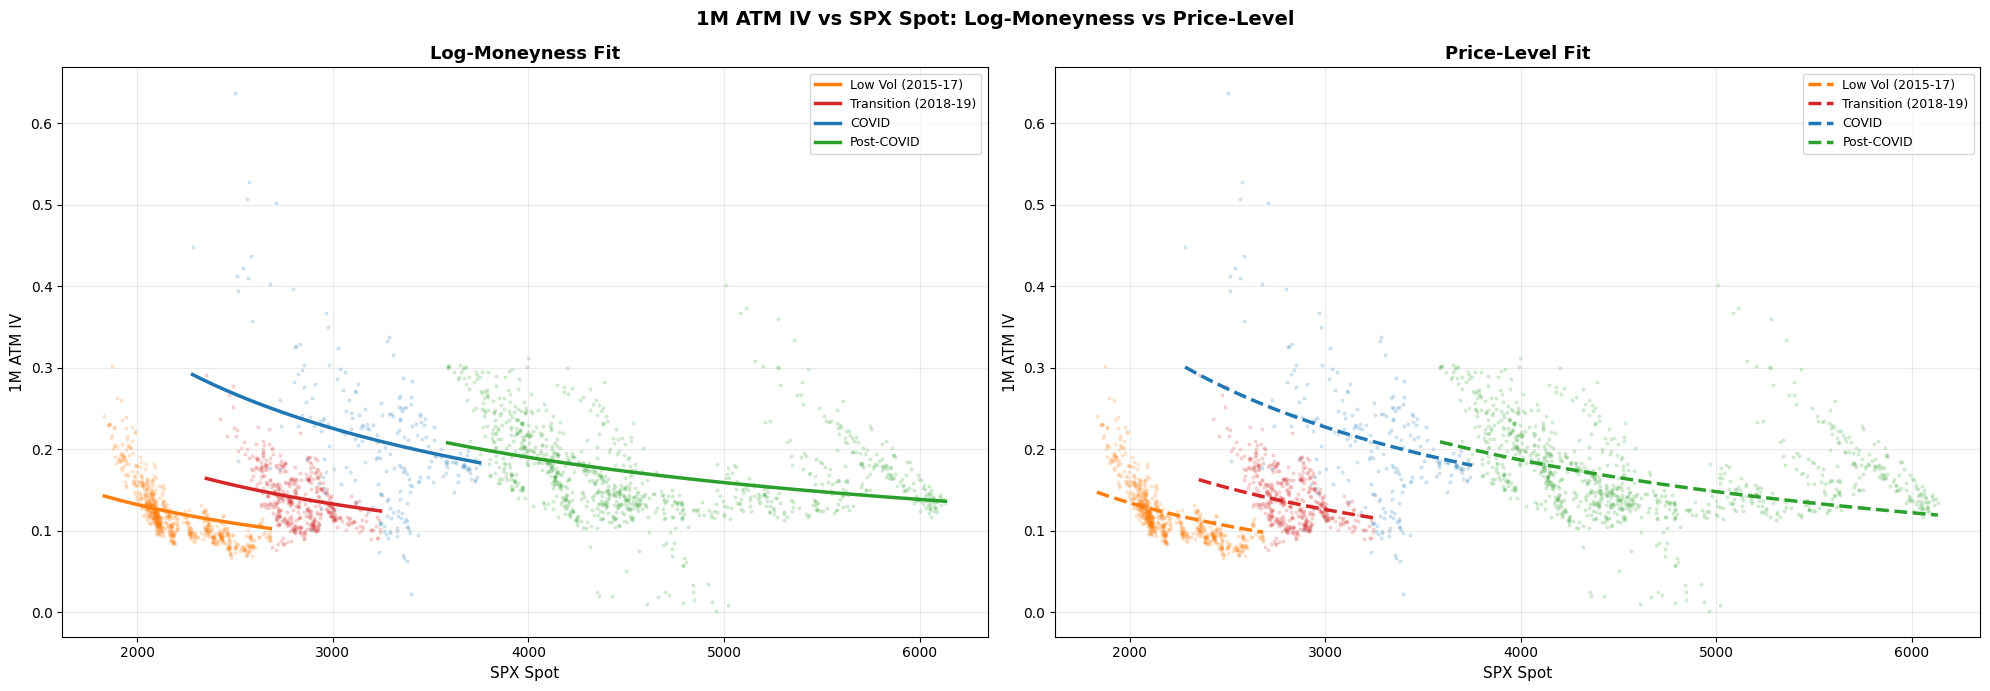

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# --- Left: Log-moneyness fits ---
for reg in regimes:
    g = iv1m_df[iv1m_df['regime'] == reg]
    ax1.scatter(g['spot'], g['atm_iv_1m'], s=4, alpha=0.15, color=regime_colors[reg])

    p_ln = fits_ln[reg]['params']
    w_ln = np.exp(p_ln[:3]) / np.sum(np.exp(p_ln[:3]))
    betas = p_ln[3:6]
    sigmas_ln = np.abs(p_ln[6:9])
    S_ref = g['spot'].mean()
    sigmas_n = list(np.array(sigmas_ln) * S_ref)

    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 200)
    fitted = []
    for S in S_grid:
        try:
            iv = op.uncertain_backbone(S, S, R, TARGET_TAU, w_ln, betas, sigmas_n, sigmas_ln)
            fitted.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            fitted.append(np.nan)

    ax1.plot(S_grid, fitted, color=regime_colors[reg], linewidth=2.5, label=reg)

ax1.set_xlabel('SPX Spot', fontsize=11)
ax1.set_ylabel('1M ATM IV', fontsize=11)
ax1.set_title('Log-Moneyness Fit', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

# --- Right: Price-level fits ---
for reg in regimes:
    g = iv1m_df[iv1m_df['regime'] == reg]
    ax2.scatter(g['spot'], g['atm_iv_1m'], s=4, alpha=0.15, color=regime_colors[reg])

    p_pr = fits_price[reg]['params']
    w_pr = np.exp(p_pr[:3]) / np.sum(np.exp(p_pr[:3]))
    sigmas_N = np.abs(p_pr[3:6])

    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 200)
    fitted = []
    for S in S_grid:
        try:
            iv = uncertain_backbone_price(S, S, R, TARGET_TAU, w_pr, sigmas_N)
            fitted.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            fitted.append(np.nan)

    ax2.plot(S_grid, fitted, color=regime_colors[reg], linewidth=2.5, linestyle='--', label=reg)

ax2.set_xlabel('SPX Spot', fontsize=11)
ax2.set_ylabel('1M ATM IV', fontsize=11)
ax2.set_title('Price-Level Fit', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.suptitle('1M ATM IV vs SPX Spot: Log-Moneyness vs Price-Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Parameter Comparison

In [10]:
print('=' * 90)
print(f'{"Regime":<25s} | {"Model":<14s} | {"w1":>6s} {"w2":>6s} {"w3":>6s} | {"\u03b2/\u03c3_N_1":>10s} {"\u03b2/\u03c3_N_2":>10s} {"\u03c3_ln/\u03c3_N_3":>10s} | MSE')
print('-' * 90)

for reg in regimes:
    # Log-moneyness
    p = fits_ln[reg]['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    betas = p[3:6]
    sigmas_ln = np.abs(p[6:9])
    mse_ln = fits_ln[reg]['fun']
    print(f'{reg:<25s} | {"Log-moneyness":<14s} | {w[0]:.4f} {w[1]:.4f} {w[2]:.4f} | {betas[0]:10.4f} {betas[1]:10.4f} {sigmas_ln[2]:10.4f} | {mse_ln:.6f}')
    print(f'{"":<25s} | {"":<14s} | {"":<6s} {"":<6s} {"":<6s} | \u03c3_ln={sigmas_ln[0]:.4f}  \u03c3_ln={sigmas_ln[1]:.4f}  \u03c3_ln={sigmas_ln[2]:.4f}')

    # Price-level
    p2 = fits_price[reg]['params']
    w2 = np.exp(p2[:3]) / np.sum(np.exp(p2[:3]))
    sigmas_N = np.abs(p2[3:6])
    mse_pr = fits_price[reg]['fun']
    print(f'{reg:<25s} | {"Price-level":<14s} | {w2[0]:.4f} {w2[1]:.4f} {w2[2]:.4f} | {sigmas_N[0]:10.4f} {sigmas_N[1]:10.4f} {sigmas_N[2]:10.4f} | {mse_pr:.6f}')
    print('-' * 90)

print()
print('Note: Log-moneyness \u03b2 values shown as \u03b2/\u03c3_N, Price-level shows raw \u03c3_N values.')
print('Log-moneyness has 9 params (3w + 3\u03b2 + 3\u03c3_ln), Price-level has 6 params (3w + 3\u03c3_N).')

Regime                    | Model          |     w1     w2     w3 |    β/σ_N_1    β/σ_N_2 σ_ln/σ_N_3 | MSE
------------------------------------------------------------------------------------------
Low Vol (2015-17)         | Log-moneyness  | 0.3873 0.3404 0.2723 |     0.8950     0.9014     0.3434 | 0.000795
                          |                |                      | σ_ln=0.0100  σ_ln=0.0100  σ_ln=0.3434
Low Vol (2015-17)         | Price-level    | 0.1902 0.2013 0.6085 |    50.0012   150.0022   400.0037 | 0.000722
------------------------------------------------------------------------------------------
Transition (2018-19)      | Log-moneyness  | 0.3839 0.3382 0.2779 |     0.8839     0.8913     0.4008 | 0.000907
                          |                |                      | σ_ln=0.0100  σ_ln=0.0100  σ_ln=0.4008
Transition (2018-19)      | Price-level    | 0.0000 0.0000 1.0000 |    50.0059   150.0180   400.0548 | 0.000904
---------------------------------------------------

## 8. Normalised Parameter Comparison

To make the comparison more meaningful, we examine the *effective* normal vol that each state contributes at the mean spot of each regime. For the log-moneyness model, the effective normal vol is $\sigma_{n,i} = \sigma_{ln,i} \cdot \bar{S}$; for the price-level model it is $\sigma_{N,i}$ directly.

In [11]:
print('=' * 95)
print(f'{"Regime":<25s} | {"Model":<14s} | {"w1":>6s} {"w2":>6s} {"w3":>6s} | {"\u03c3eff_1":>8s} {"\u03c3eff_2":>8s} {"\u03c3eff_3":>8s} | MSE')
print('-' * 95)

for reg in regimes:
    S_ref = iv1m_df[iv1m_df['regime'] == reg]['spot'].mean()

    # Log-moneyness effective normal vols
    p = fits_ln[reg]['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    sigmas_ln = np.abs(p[6:9])
    sigmas_n_eff = sigmas_ln * S_ref
    mse_ln = fits_ln[reg]['fun']
    print(f'{reg:<25s} | {"Log-moneyness":<14s} | {w[0]:.4f} {w[1]:.4f} {w[2]:.4f} | {sigmas_n_eff[0]:8.2f} {sigmas_n_eff[1]:8.2f} {sigmas_n_eff[2]:8.2f} | {mse_ln:.6f}')

    # Price-level normal vols
    p2 = fits_price[reg]['params']
    w2 = np.exp(p2[:3]) / np.sum(np.exp(p2[:3]))
    sigmas_N = np.abs(p2[3:6])
    mse_pr = fits_price[reg]['fun']
    print(f'{reg:<25s} | {"Price-level":<14s} | {w2[0]:.4f} {w2[1]:.4f} {w2[2]:.4f} | {sigmas_N[0]:8.2f} {sigmas_N[1]:8.2f} {sigmas_N[2]:8.2f} | {mse_pr:.6f}')
    print('-' * 95)

print()
print('\u03c3eff columns show effective normal vol in price units/\u221ayr.')
print('For log-moneyness: \u03c3eff = \u03c3_ln \u00d7 S_mean(ref).  For price-level: \u03c3eff = \u03c3_N directly.')

Regime                    | Model          |     w1     w2     w3 |   σeff_1   σeff_2   σeff_3 | MSE
-----------------------------------------------------------------------------------------------
Low Vol (2015-17)         | Log-moneyness  | 0.3873 0.3404 0.2723 |    21.98    21.98   754.70 | 0.000795
Low Vol (2015-17)         | Price-level    | 0.1902 0.2013 0.6085 |    50.00   150.00   400.00 | 0.000722
-----------------------------------------------------------------------------------------------
Transition (2018-19)      | Log-moneyness  | 0.3839 0.3382 0.2779 |    28.27    28.27  1132.91 | 0.000907
Transition (2018-19)      | Price-level    | 0.0000 0.0000 1.0000 |    50.01   150.02   400.05 | 0.000904
-----------------------------------------------------------------------------------------------
COVID                     | Log-moneyness  | 0.2536 0.2606 0.4858 |    32.39    32.39   763.52 | 0.005632
COVID                     | Price-level    | 0.0000 0.0000 1.0000 |    50.05   15

## 9. Residual Analysis

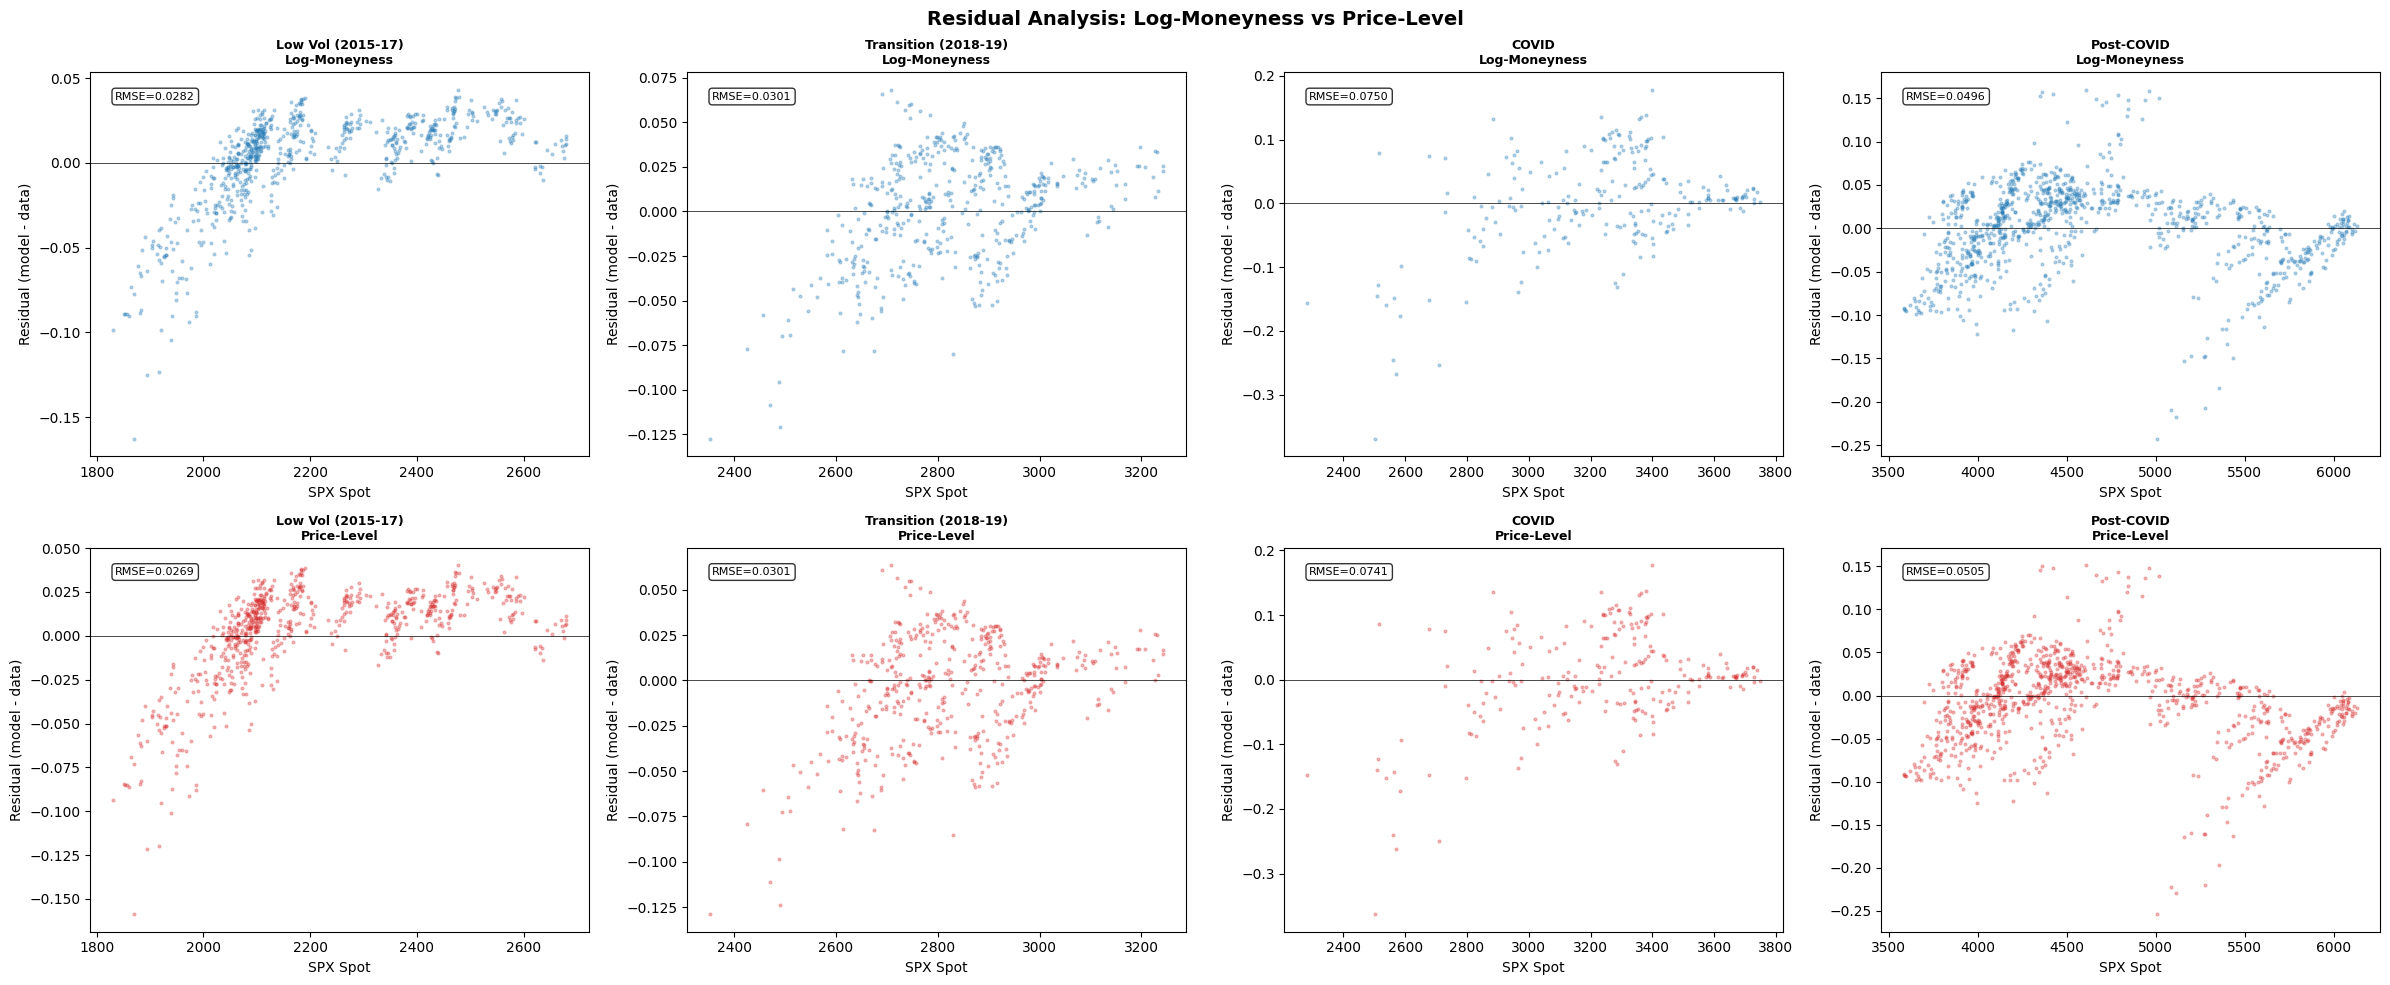

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for idx, reg in enumerate(regimes):
    g = iv1m_df[iv1m_df['regime'] == reg]
    S_data = g['spot'].values
    iv_data = g['atm_iv_1m'].values

    # --- Log-moneyness residuals ---
    p = fits_ln[reg]['params']
    w_ln = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    betas = p[3:6]
    sigmas_ln = np.abs(p[6:9])
    S_ref_ln = g['spot'].mean()
    sigmas_n_ln = list(np.array(sigmas_ln) * S_ref_ln)

    resid_ln = []
    for j, S in enumerate(S_data):
        try:
            iv_model = op.uncertain_backbone(S, S, R, TARGET_TAU, w_ln, betas, sigmas_n_ln, sigmas_ln)
            if np.isnan(iv_model):
                resid_ln.append(np.nan)
            else:
                resid_ln.append(iv_model - iv_data[j])
        except Exception:
            resid_ln.append(np.nan)

    axes[0, idx].scatter(S_data, resid_ln, s=4, alpha=0.3, color='#1f77b4')
    axes[0, idx].axhline(0, color='black', linewidth=0.5)
    axes[0, idx].set_title(f'{reg}\nLog-Moneyness', fontsize=9, fontweight='bold')
    axes[0, idx].set_xlabel('SPX Spot')
    axes[0, idx].set_ylabel('Residual (model - data)')
    rmse_ln = np.sqrt(np.nanmean(np.array(resid_ln)**2))
    axes[0, idx].text(0.05, 0.95, f'RMSE={rmse_ln:.4f}', transform=axes[0, idx].transAxes,
                     fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # --- Price-level residuals ---
    p2 = fits_price[reg]['params']
    w_pr = np.exp(p2[:3]) / np.sum(np.exp(p2[:3]))
    sigmas_N = np.abs(p2[3:6])

    resid_pr = []
    for j, S in enumerate(S_data):
        try:
            iv_model = uncertain_backbone_price(S, S, R, TARGET_TAU, w_pr, sigmas_N)
            if np.isnan(iv_model):
                resid_pr.append(np.nan)
            else:
                resid_pr.append(iv_model - iv_data[j])
        except Exception:
            resid_pr.append(np.nan)

    axes[1, idx].scatter(S_data, resid_pr, s=4, alpha=0.3, color='#d62728')
    axes[1, idx].axhline(0, color='black', linewidth=0.5)
    axes[1, idx].set_title(f'{reg}\nPrice-Level', fontsize=9, fontweight='bold')
    axes[1, idx].set_xlabel('SPX Spot')
    axes[1, idx].set_ylabel('Residual (model - data)')
    rmse_pr = np.sqrt(np.nanmean(np.array(resid_pr)**2))
    axes[1, idx].text(0.05, 0.95, f'RMSE={rmse_pr:.4f}', transform=axes[1, idx].transAxes,
                      fontsize=8, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Residual Analysis: Log-Moneyness vs Price-Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary

In [13]:
summary_rows = []
for reg in regimes:
    S_ref = iv1m_df[iv1m_df['regime'] == reg]['spot'].mean()
    n_obs = len(iv1m_df[iv1m_df['regime'] == reg])

    ln_info = fits_ln[reg]
    pr_info = fits_price[reg]

    summary_rows.append({
        'regime': reg,
        'n_obs': n_obs,
        'model': 'Log-moneyness',
        'n_params': 9,
        'mse': ln_info['fun'],
        'converged': ln_info['success'],
    })
    summary_rows.append({
        'regime': reg,
        'n_obs': n_obs,
        'model': 'Price-level',
        'n_params': 6,
        'mse': pr_info['fun'],
        'converged': pr_info['success'],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print()
print('Log-moneyness uses 9 parameters (3 weights + 3 betas + 3 sigma_ln).')
print('Price-level uses 6 parameters (3 weights + 3 sigma_N).')
print('Both models are evaluated on the same ATM data, so MSE is directly comparable.')

              regime  n_obs         model  n_params      mse  converged
   Low Vol (2015-17)    705 Log-moneyness         9 0.000795       True
   Low Vol (2015-17)    705   Price-level         6 0.000722       True
Transition (2018-19)    471 Log-moneyness         9 0.000907       True
Transition (2018-19)    471   Price-level         6 0.000904       True
               COVID    234 Log-moneyness         9 0.005632       True
               COVID    234   Price-level         6 0.005488       True
          Post-COVID    995 Log-moneyness         9 0.002463       True
          Post-COVID    995   Price-level         6 0.002549       True

Log-moneyness uses 9 parameters (3 weights + 3 betas + 3 sigma_ln).
Price-level uses 6 parameters (3 weights + 3 sigma_N).
Both models are evaluated on the same ATM data, so MSE is directly comparable.
